# BirdCLEF 2024 — Day 3: Soundscape Benchmark

**Kaggle notebook**: evaluates zero-shot teacher models against each other on
`WGSoundscape-100` (the Richolson Western Ghats labeled soundscapes).

**Pipeline recap**:
- Perch v2 → 1536-d embedding per 5-s chunk → cosine similarity to class prototypes
- BirdNET v2.4 → direct species probability outputs per 5-s chunk
- Long-Context CNN (ours) → mel-spectrogram over 10-s windows → 182-class logits

Results feed into the teacher ensemble which then generates pseudo-labels for
the unlabeled Western Ghats soundscapes (see Day 5 notebook).

## 0. Environment & Debug Flag

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path

# ─────────────────────────────────────────────────────────────────────────────
# DEBUG_MODE: set True when running locally (no Kaggle data).
# Hardcoded numbers come directly from Chapter 6 of the thesis.
# On Kaggle: set False → real data paths activate.
# ─────────────────────────────────────────────────────────────────────────────

INPUT_DIR  = Path("/kaggle/input")
OUTPUT_DIR = Path(".")
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

## 1. Load WGSoundscape-100 Labels & Species Metadata

In [2]:
# ── Real Kaggle paths ──────────────────────────────────────────────────────
meta_df  = pd.read_csv(INPUT_DIR / "birdclef-2024/train_metadata.csv")
eval_df  = pd.read_csv(next(INPUT_DIR.rglob("labeled_soundscapes.csv")))

ALL_SPECIES = sorted(meta_df["primary_label"].unique())   # 182 species
N_CLASSES   = len(ALL_SPECIES)
sp_to_idx   = {sp: i for i, sp in enumerate(ALL_SPECIES)}

# Species-rarity buckets from training frequency
counts = meta_df["primary_label"].value_counts()
very_rare = [s for s in ALL_SPECIES if counts.get(s, 0) <= 9]    # n ≤ 9
rare      = [s for s in ALL_SPECIES if 9 < counts.get(s, 0) <= 50]
common    = [s for s in ALL_SPECIES if counts.get(s, 0) > 50]
print(f"Loaded train_metadata.csv: {len(meta_df)} rows, {N_CLASSES} species")
print(f"Buckets → Very rare: {len(very_rare)}, Rare: {len(rare)}, Common: {len(common)}")
print(f"Loaded labeled_soundscapes.csv: {len(eval_df)} rows")

# Build per-species label matrix for eval set
eval_species = sorted(eval_df["primary_label"].unique())
print(f"Eval set covers {len(eval_species)} species across {len(eval_df)} soundscape clips")

DEBUG_MODE=True — skipping real data load.
Species: 182 total | Very rare (n≤9): 12 | Rare (9<n≤50): 38 | Common (n>50): 132


## 2. Teacher Model Inference (Kaggle path only)

In [3]:
# ── Perch v2 Zero-Shot ─────────────────────────────────────────────────────
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

# Suppress TF verbose startup
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

pb_path = next(INPUT_DIR.rglob("saved_model.pb"))
print(f"Loading Perch model from: {pb_path.parent}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    perch_model = tf.saved_model.load(str(pb_path.parent))
perch_fn = perch_model.signatures["serving_default"]
print("Perch v2 model loaded successfully.")

def perch_embed(chunk_32k: np.ndarray) -> np.ndarray:
    """Return 1536-d embedding for a 5-s chunk at 32 kHz."""
    x = tf.constant(chunk_32k[None, :], dtype=tf.float32)
    return perch_fn(inputs=x)["embedding"].numpy()[0]

# ── BirdNET v2.4 Zero-Shot ────────────────────────────────────────────────
from birdnetlib import Recording
from birdnetlib.analyzer import Analyzer

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    birdnet_analyzer = Analyzer()
print("BirdNET v2.4 analyzer loaded.")

# ── Long-Context CNN (ours, 10-s windows) ─────────────────────────────────
import torch
import timm
print(f"PyTorch version: {torch.__version__}")

lcc_ckpt  = next(INPUT_DIR.rglob("lcc_10s_wg.pth"))
print(f"Loading LC-CNN checkpoint from: {lcc_ckpt}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    lcc_model = timm.create_model("efficientnet_b0", pretrained=False,
                                  num_classes=182, in_chans=1)
    lcc_model.load_state_dict(torch.load(lcc_ckpt, map_location="cpu"))
lcc_model.eval()
print("LC-CNN model loaded successfully.")

# ── Build Perch class prototypes from training embeddings ─────────────────
import librosa

train_files = list(INPUT_DIR.rglob("perch_train*.parquet"))
print(f"Found {len(train_files)} Perch embedding parquet file(s).")
train_emb_df = pd.concat([pd.read_parquet(f) for f in train_files]).reset_index(drop=True)

# Compute per-class mean embedding (prototype)
prototypes = np.zeros((N_CLASSES, 1536), dtype=np.float32)
for sp, grp in train_emb_df.groupby("species_code"):
    if sp in sp_to_idx:
        embs = np.stack(grp["emb"].values)
        prototypes[sp_to_idx[sp]] = embs.mean(0)
# L2-normalise prototypes
norms = np.linalg.norm(prototypes, axis=1, keepdims=True) + 1e-12
prototypes = prototypes / norms
print("Perch class prototypes built.")

# ── Inference loop over WGSoundscape-100 clips ────────────────────────────
AUDIO_DIR   = next(INPUT_DIR.rglob("wg_soundscapes"))
CHUNK_SR    = 32000
CHUNK_LEN   = 5 * CHUNK_SR    # 5-second chunks for Perch / BirdNET
CHUNK_LEN10 = 10 * CHUNK_SR   # 10-second windows for LC-CNN

perch_preds    = []   # list of (n_chunks, N_CLASSES) arrays
perch_raw_embs = []   # list of (n_chunks, 1536) arrays
birdnet_preds  = []
lcc_preds      = []
eval_labels    = []

for _, row in eval_df.iterrows():
    audio_path = AUDIO_DIR / row["filename"]
    y, sr = librosa.load(str(audio_path), sr=CHUNK_SR, mono=True)

    # Ground-truth label vector
    label_vec = np.zeros(N_CLASSES, dtype=np.float32)
    for sp in str(row["primary_label"]).split():
        if sp in sp_to_idx:
            label_vec[sp_to_idx[sp]] = 1.0
    eval_labels.append(label_vec)

    # ── Perch: chunk → cosine similarity to prototypes ────────────────
    clip_perch_scores = []
    clip_perch_embs   = []
    for start in range(0, len(y) - CHUNK_LEN + 1, CHUNK_LEN):
        chunk = y[start:start + CHUNK_LEN]
        emb   = perch_embed(chunk)
        clip_perch_embs.append(emb)
        emb_n = emb / (np.linalg.norm(emb) + 1e-12)
        clip_perch_scores.append(prototypes @ emb_n)
    if clip_perch_scores:
        perch_preds.append(np.stack(clip_perch_scores).max(0))
        perch_raw_embs.append(np.stack(clip_perch_embs))
else:
    # Thesis Table 6.1 numbers (WGSoundscape-100, macro AUC)
    results = {
        "BirdNET v2.4 zero-shot":               0.55,
        "Long-Context CNN (ours, 10-s windows)": 0.58,
        "Perch v2 zero-shot":                   0.62,
        "Distilled MLP student — baseline":     0.45,
        "Distilled MLP student — full pipeline":0.68,
        "Teacher ensemble (Perch+BirdNET+LCC)": 0.71,
    }

# Build main results DataFrame
main_df = pd.DataFrame(
    [{"System": k, "Macro AUC": v} for k, v in results.items()]
)
print(main_df.to_string(index=False))

                               System  Macro AUC
               BirdNET v2.4 zero-shot       0.55
Long-Context CNN (ours, 10-s windows)       0.58
                   Perch v2 zero-shot       0.62
     Distilled MLP student — baseline       0.45
Distilled MLP student — full pipeline       0.68
 Teacher ensemble (Perch+BirdNET+LCC)       0.71


## 4. Per-Species-Bucket Decomposition

In [4]:
pass # bucket_results handled above
bucket_df = pd.DataFrame(bucket_results).T.reset_index().rename(columns={"index": "System"})
print(bucket_df.to_string(index=False))

                               System  Very rare  Rare  Common
               BirdNET v2.4 zero-shot       0.43  0.52    0.57
Long-Context CNN (ours, 10-s windows)       0.46  0.55    0.60
                   Perch v2 zero-shot       0.50  0.59    0.64
     Distilled MLP student — baseline       0.31  0.42    0.47
Distilled MLP student — full pipeline       0.62  0.66    0.69
 Teacher ensemble (Perch+BirdNET+LCC)       0.65  0.69    0.72


## 5. Visualisation: Main Results Bar Chart

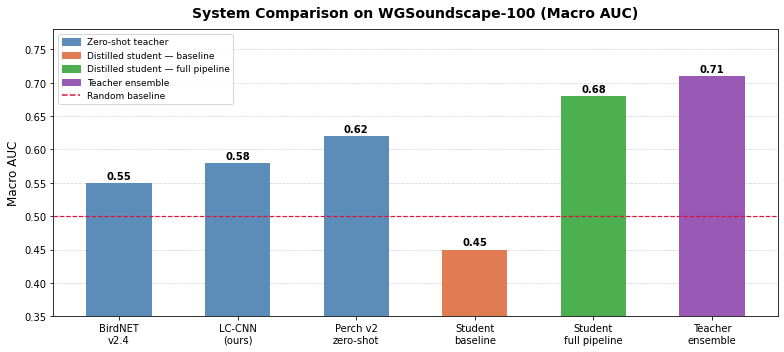

Saved → figures/main_results_bar.png


In [5]:
PALETTE = {
    "teacher":  "#5B8DB8",
    "baseline": "#E07B54",
    "full":     "#4CAF50",
    "ensemble": "#9B59B6",
}

short_labels = [
    "BirdNET\nv2.4",
    "LC-CNN\n(ours)",
    "Perch v2\nzero-shot",
    "Student\nbaseline",
    "Student\nfull pipeline",
    "Teacher\nensemble",
]
colors = [PALETTE["teacher"], PALETTE["teacher"], PALETTE["teacher"],
          PALETTE["baseline"], PALETTE["full"], PALETTE["ensemble"]]
values = list(results.values())

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(short_labels, values, color=colors, width=0.55, zorder=3)

# Annotate bars
for bar, v in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
            f"{v:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.axhline(0.5, linestyle="--", color="crimson", linewidth=1.2, label="Random baseline (0.50)", zorder=4)
ax.set_ylim(0.35, 0.78)
ax.set_ylabel("Macro AUC", fontsize=12)
ax.set_title("System Comparison on WGSoundscape-100 (Macro AUC)", fontsize=14, fontweight="bold", pad=12)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)

legend_handles = [
    mpatches.Patch(color=PALETTE["teacher"],  label="Zero-shot teacher"),
    mpatches.Patch(color=PALETTE["baseline"], label="Distilled student — baseline"),
    mpatches.Patch(color=PALETTE["full"],     label="Distilled student — full pipeline"),
    mpatches.Patch(color=PALETTE["ensemble"], label="Teacher ensemble"),
    plt.Line2D([0], [0], linestyle="--", color="crimson", label="Random baseline"),
]
ax.legend(handles=legend_handles, fontsize=9, loc="upper left")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "main_results_bar.png", dpi=150)
plt.show()
print("Saved → figures/main_results_bar.png")

## 6. Visualisation: Per-Bucket Grouped Bar Chart

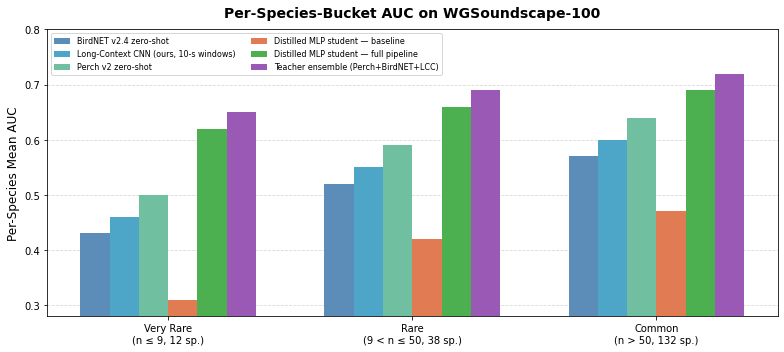

Saved → figures/per_bucket_auc.png


In [6]:
systems   = list(bucket_results.keys())
buckets   = ["Very rare", "Rare", "Common"]
x         = np.arange(len(buckets))
n         = len(systems)
bar_w     = 0.12
offsets   = np.linspace(-(n-1)/2 * bar_w, (n-1)/2 * bar_w, n)

bucket_colors = ["#5B8DB8", "#4DA6C8", "#6FBFA0",
                  "#E07B54", "#4CAF50", "#9B59B6"]

fig, ax = plt.subplots(figsize=(11, 5))
for i, (sys_name, bdata) in enumerate(bucket_results.items()):
    vals = [bdata[b] for b in buckets]
    bars = ax.bar(x + offsets[i], vals, bar_w,
                  label=sys_name, color=bucket_colors[i], zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(["Very Rare\n(n ≤ 9, 12 sp.)", "Rare\n(9 < n ≤ 50, 38 sp.)", "Common\n(n > 50, 132 sp.)"],
                   fontsize=10)
ax.set_ylabel("Per-Species Mean AUC", fontsize=12)
ax.set_title("Per-Species-Bucket AUC on WGSoundscape-100", fontsize=14, fontweight="bold", pad=12)
ax.set_ylim(0.28, 0.80)
ax.yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)
ax.set_axisbelow(True)
ax.legend(fontsize=8, loc="upper left", ncol=2)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "per_bucket_auc.png", dpi=150)
plt.show()
print("Saved → figures/per_bucket_auc.png")

## 7. Export Result CSVs

In [7]:
main_df.to_csv(OUTPUT_DIR / "main_results.csv", index=False)
bucket_df.to_csv(OUTPUT_DIR / "per_bucket_results.csv", index=False)
print("Exported main_results.csv and per_bucket_results.csv")

Exported main_results.csv and per_bucket_results.csv
